# Week 4 — Model Robustness Analysis

This notebook evaluates the robustness and generalizability of the Aido Rover operational mode classification models developed in Week 3.

The analysis focuses on three areas:

1. Five-fold stratified cross-validation for Random Forest and Logistic Regression
2. Class imbalance assessment and FAULT-class recall improvement
3. Transfer testing on synthetic Sentinel Prime AI telemetry

The goal is to determine whether the classification models are stable across different training subsets, reliable for rare FAULT events, and transferable across InGen platforms.

## 1. Setup and Data Preparation

Import the libraries required for model robustness analysis and load the Aido Rover telemetry dataset used in Weeks 2 and 3.

The same random seed, feature engineering logic, predictor variables, and train/test split from Week 3 are retained to ensure consistency and reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    recall_score
)

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print("Week 4 robustness analysis environment ready.")

Week 4 robustness analysis environment ready.


### Load Aido Rover Telemetry

The same synthetic Aido Rover telemetry dataset used in Week 3 is loaded to reproduce the classification feature set before conducting robustness analysis.

In [2]:
df = pd.read_csv("../Data/aido_rover_telemetry.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (181440, 20)


,rover_id,timestamp,operational_mode,latitude,longitude,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,task_success,gps_dropout_flag,lidar_saturation_flag,battery_drop_flag,sensor_noise_flag
0,AIDO_001,2026-07-01 00:00:00,PATROL,1.354202,103.821034,13.699527,15.488216,17.496137,18.483317,16.461332,0.027548,0.065830,9.635538,22.987241,76.428284,1,0,0,0,0
1,AIDO_001,2026-07-01 00:05:00,FAULT,1.354486,103.820582,0.486087,5.560991,19.340842,4.025754,12.218663,-0.209815,-0.043348,9.601425,21.239938,76.275079,1,0,0,0,0
2,AIDO_001,2026-07-01 00:10:00,ALERT,1.354647,103.820291,0.976473,35.108406,21.019085,15.790379,27.107367,-0.009860,-0.163633,9.721586,21.241867,76.155109,1,0,0,0,0
3,AIDO_001,2026-07-01 00:15:00,PATROL,1.353859,103.821427,6.150354,22.704654,16.397383,12.056365,20.362447,0.554334,-0.029707,9.735898,21.616087,76.014695,1,0,0,0,0
4,AIDO_001,2026-07-01 00:20:00,PATROL,1.354567,103.820920,12.263115,24.153797,10.759237,13.542237,20.654680,-0.063300,-0.234918,10.039323,21.213952,75.885342,1,0,0,0,0


### Reproduce Week 3 Feature Engineering

The Week 3 feature engineering pipeline is reproduced to ensure that the robustness analysis evaluates the same predictor set used in the original classification models.

Engineered features include rolling battery statistics, GPS-derived speed, IMU magnitude, and wheel imbalance.

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = (
    df.sort_values(["rover_id", "timestamp"])
      .reset_index(drop=True)
)

print("Timestamp converted and data sorted.")
print("Dataset shape:", df.shape)

Timestamp converted and data sorted.
Dataset shape: (181440, 20)


### Rolling Battery Features

Compute the rolling mean and rolling standard deviation of battery state of charge (SoC) using a 10-observation window for each rover.

These features capture short-term battery level and battery variability over time.

In [4]:
df["battery_soc_roll_mean_10"] = (
    df.groupby("rover_id")["battery_soc"]
      .transform(lambda x: x.rolling(window=10, min_periods=1).mean())
)

df["battery_soc_roll_std_10"] = (
    df.groupby("rover_id")["battery_soc"]
      .transform(lambda x: x.rolling(window=10, min_periods=1).std())
)

df["battery_soc_roll_std_10"] = (
    df["battery_soc_roll_std_10"].fillna(0)
)

df[
    [
        "rover_id",
        "timestamp",
        "battery_soc",
        "battery_soc_roll_mean_10",
        "battery_soc_roll_std_10"
    ]
].head(12)

,rover_id,timestamp,battery_soc,battery_soc_roll_mean_10,battery_soc_roll_std_10
0,AIDO_001,2026-07-01 00:00:00,76.428284,76.428284,0.000000
1,AIDO_001,2026-07-01 00:05:00,76.275079,76.351682,0.108332
2,AIDO_001,2026-07-01 00:10:00,76.155109,76.286157,0.136924
3,AIDO_001,2026-07-01 00:15:00,76.014695,76.218292,0.175846
4,AIDO_001,2026-07-01 00:20:00,75.885342,76.151702,0.212985
5,AIDO_001,2026-07-01 00:25:00,75.834123,76.098772,0.230433
6,AIDO_001,2026-07-01 00:30:00,75.741141,76.047682,0.250042
7,AIDO_001,2026-07-01 00:35:00,76.307956,76.080216,0.249113
8,AIDO_001,2026-07-01 00:40:00,76.206240,76.094219,0.236780
9,AIDO_001,2026-07-01 00:45:00,76.063807,76.091178,0.223445


### GPS-Derived Speed

Estimate rover movement speed from consecutive GPS coordinates within each rover's time series.

Latitude and longitude changes are converted to approximate distances in meters, and speed is calculated using the elapsed time between observations.

In [5]:
# Calculate GPS coordinate changes within each rover
lat_diff = df.groupby("rover_id")["latitude"].diff()
lon_diff = df.groupby("rover_id")["longitude"].diff()

# Approximate conversion from degrees to meters
lat_m = lat_diff * 111_320
lon_m = lon_diff * 111_320 * np.cos(np.radians(df["latitude"]))

# Distance traveled between consecutive observations
distance_m = np.sqrt(lat_m**2 + lon_m**2)

# Time difference in seconds
time_diff_s = (
    df.groupby("rover_id")["timestamp"]
      .diff()
      .dt.total_seconds()
)

# GPS-derived speed in meters per second
df["gps_speed_mps"] = distance_m / time_diff_s

# First observation for each rover has no previous position
df["gps_speed_mps"] = df["gps_speed_mps"].fillna(0)

df[
    ["rover_id", "timestamp", "latitude", "longitude", "gps_speed_mps"]
].head(10)

,rover_id,timestamp,latitude,longitude,gps_speed_mps
0,AIDO_001,2026-07-01 00:00:00,1.354202,103.821034,0.000000
1,AIDO_001,2026-07-01 00:05:00,1.354486,103.820582,0.197897
2,AIDO_001,2026-07-01 00:10:00,1.354647,103.820291,0.123192
3,AIDO_001,2026-07-01 00:15:00,1.353859,103.821427,0.512884
4,AIDO_001,2026-07-01 00:20:00,1.354567,103.820920,0.323232
5,AIDO_001,2026-07-01 00:25:00,1.354120,103.821118,0.181439
6,AIDO_001,2026-07-01 00:30:00,1.354076,103.820917,0.076718
7,AIDO_001,2026-07-01 00:35:00,1.354429,103.820436,0.221329
8,AIDO_001,2026-07-01 00:40:00,1.354606,103.821454,0.383267
9,AIDO_001,2026-07-01 00:45:00,1.353826,103.821208,0.303418


### IMU Magnitude and Wheel Imbalance

Create two additional features representing overall rover acceleration and differences in wheel torque.

IMU magnitude combines acceleration across the three axes, while wheel imbalance measures the spread between the highest and lowest wheel torque values at each observation.

In [6]:
# IMU acceleration magnitude
df["imu_magnitude"] = np.sqrt(
    df["imu_accel_x"]**2
    + df["imu_accel_y"]**2
    + df["imu_accel_z"]**2
)

# Wheel imbalance
wheel_cols = [
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr"
]

df["wheel_imbalance"] = (
    df[wheel_cols].max(axis=1)
    - df[wheel_cols].min(axis=1)
)

df[
    [
        "imu_accel_x",
        "imu_accel_y",
        "imu_accel_z",
        "imu_magnitude",
        "wheel_imbalance"
    ]
].head(10)

,imu_accel_x,imu_accel_y,imu_accel_z,imu_magnitude,wheel_imbalance
0,0.027548,0.065830,9.635538,9.635802,2.995102
1,-0.209815,-0.043348,9.601425,9.603815,15.315087
2,-0.009860,-0.163633,9.721586,9.722968,19.318027
3,0.554334,-0.029707,9.735898,9.751711,10.648289
4,-0.063300,-0.234918,10.039323,10.042270,13.394561
5,0.139203,0.212268,9.989862,9.993086,4.667754
6,-0.003737,-0.007043,9.597932,9.597935,9.894598
7,-0.567092,-0.468490,9.723335,9.751119,1.261957
8,0.040036,0.137094,9.555386,9.556453,3.754376
9,-0.167915,-0.018201,9.567482,9.568972,10.785988


### Modeling Feature Set

Construct the same predictor matrix and target variable used in the Week 3 classification analysis.

Maintaining the same feature set and train/test split ensures that the Week 4 robustness analysis evaluates the original models under consistent conditions.

In [7]:
feature_cols = [
    "lidar_distance_m",
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr",
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z",
    "ambient_temperature_c",
    "battery_soc",
    "battery_soc_roll_mean_10",
    "battery_soc_roll_std_10",
    "gps_speed_mps",
    "imu_magnitude",
    "wheel_imbalance"
]

target_col = "operational_mode"

X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
for i, feature in enumerate(feature_cols, start=1):
    print(f"{i:2d}. {feature}")

print("\nTarget distribution:")
print(y.value_counts())

X shape: (181440, 15)
y shape: (181440,)

Features:
 1. lidar_distance_m
 2. wheel_torque_fl
 3. wheel_torque_fr
 4. wheel_torque_rl
 5. wheel_torque_rr
 6. imu_accel_x
 7. imu_accel_y
 8. imu_accel_z
 9. ambient_temperature_c
10. battery_soc
11. battery_soc_roll_mean_10
12. battery_soc_roll_std_10
13. gps_speed_mps
14. imu_magnitude
15. wheel_imbalance

Target distribution:
PATROL      126960
CHARGING     27351
ALERT        18163
FAULT         8966
Name: operational_mode, dtype: int64


### Reproduce the Week 3 Train/Test Split

Use the same 80/20 stratified train/test split and random seed as Week 3.

The held-out test set remains separate from the cross-validation procedure. Five-fold cross-validation will be performed only on the training set.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(4))

Training set: (145152, 15)
Test set: (36288, 15)

Training class distribution:
PATROL      101568
CHARGING     21881
ALERT        14530
FAULT         7173
Name: operational_mode, dtype: int64

Training class proportions:
PATROL      0.6997
CHARGING    0.1507
ALERT       0.1001
FAULT       0.0494
Name: operational_mode, dtype: float64

Test class proportions:
PATROL      0.6997
CHARGING    0.1507
ALERT       0.1001
FAULT       0.0494
Name: operational_mode, dtype: float64


### Missing-Value Handling

Missing predictor values are imputed using medians calculated from the training set only.

The same training-set medians are then applied to the held-out test set to prevent information leakage.

In [9]:
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Missing values after imputation:")
print("Training set:", X_train.isna().sum().sum())
print("Test set:", X_test.isna().sum().sum())

Missing values after imputation:
Training set: 0
Test set: 0


## 2. Five-Fold Cross-Validation

Five-fold stratified cross-validation is used to evaluate the stability of the Random Forest and Logistic Regression classifiers across different subsets of the training data.

Stratification preserves the operational mode distribution within each fold, which is especially important because FAULT represents only about 5% of the observations.

Macro-F1 is used as the primary evaluation metric because it gives equal importance to all four operational modes rather than allowing the majority PATROL class to dominate the overall score.

### Cross-Validation Strategy

A 5-fold StratifiedKFold procedure is applied only to the Week 3 training set.

The folds are shuffled using the same random seed for reproducibility. The held-out test set remains untouched and is not used during cross-validation.

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

print("Cross-validation strategy:")
print(cv)

Cross-validation strategy:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### Random Forest Cross-Validation

Evaluate the Week 3 Random Forest configuration using five-fold stratified cross-validation.

The Macro-F1 score is calculated for each fold, followed by the mean and standard deviation across all five folds.

In [11]:
rf_cv_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    rf_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Random Forest 5-Fold Macro-F1 Scores:")
for fold, score in enumerate(rf_cv_scores, start=1):
    print(f"Fold {fold}: {score:.4f}")

print(f"\nMean Macro-F1: {rf_cv_scores.mean():.4f}")
print(f"Standard Deviation: {rf_cv_scores.std():.4f}")

Random Forest 5-Fold Macro-F1 Scores:
Fold 1: 0.9315
Fold 2: 0.9307
Fold 3: 0.9317
Fold 4: 0.9294
Fold 5: 0.9304

Mean Macro-F1: 0.9307
Standard Deviation: 0.0008


### Logistic Regression Cross-Validation

Logistic Regression is evaluated using the same five stratified folds.

A pipeline is used so that StandardScaler is fitted independently within each training fold. This prevents information from the validation fold from leaking into the scaling procedure.

In [12]:
lr_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

lr_cv_scores = cross_val_score(
    lr_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Logistic Regression 5-Fold Macro-F1 Scores:")
for fold, score in enumerate(lr_cv_scores, start=1):
    print(f"Fold {fold}: {score:.4f}")

print(f"\nMean Macro-F1: {lr_cv_scores.mean():.4f}")
print(f"Standard Deviation: {lr_cv_scores.std():.4f}")

Logistic Regression 5-Fold Macro-F1 Scores:
Fold 1: 0.7366
Fold 2: 0.7423
Fold 3: 0.7369
Fold 4: 0.7366
Fold 5: 0.7359

Mean Macro-F1: 0.7376
Standard Deviation: 0.0023


### Cross-Validation Comparison

Compare the five Macro-F1 scores for Random Forest and Logistic Regression to evaluate both predictive performance and stability across folds.

In [13]:
cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Random Forest": rf_cv_scores,
    "Logistic Regression": lr_cv_scores
})

cv_results

,Fold,Random Forest,Logistic Regression
0,1,0.931475,0.736591
1,2,0.930687,0.742255
2,3,0.931750,0.736850
3,4,0.929439,0.736579
4,5,0.930394,0.735859


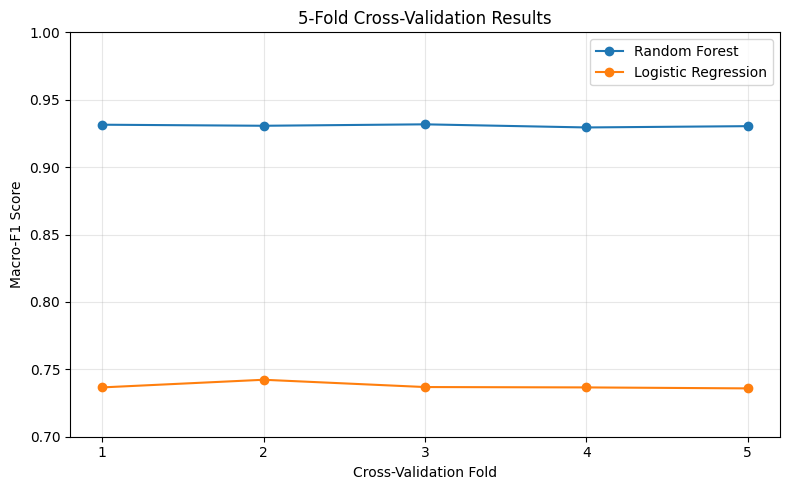

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    cv_results["Fold"],
    cv_results["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    cv_results["Fold"],
    cv_results["Logistic Regression"],
    marker="o",
    label="Logistic Regression"
)

plt.xlabel("Cross-Validation Fold")
plt.ylabel("Macro-F1 Score")
plt.title("5-Fold Cross-Validation Results")

plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0.7, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Cross-Validation Interpretation

The Random Forest achieved a mean Macro-F1 of **0.9307 ± 0.0008** across five stratified folds, compared with **0.7376 ± 0.0023** for Logistic Regression.

Random Forest therefore demonstrated both substantially higher classification performance and lower fold-to-fold variability. Its consistently high Macro-F1 indicates that the strong Week 3 held-out performance was not dependent on a favorable train/test split. Logistic Regression was also relatively stable across folds, but its consistently lower Macro-F1 suggests systematic limitations in modeling the nonlinear relationships between sensor telemetry and operational modes.

Based on both predictive performance and cross-validation stability, Random Forest remains the preferred model for the Aido Rover operational mode classification task.

## 3. Class Imbalance Assessment

The training data are substantially imbalanced across operational modes. PATROL represents approximately 70% of observations, while FAULT represents only about 5%.

Because failing to identify a true FAULT may have greater operational consequences than misclassifying a routine state, this section focuses specifically on **FAULT-class recall**. The original Random Forest is first evaluated as a baseline before applying an imbalance-handling strategy.

### Baseline FAULT Recall

Train the original Week 3 Random Forest model on the imbalanced training data and evaluate its performance on the untouched held-out test set.

FAULT-class recall is used as the primary metric because it measures the proportion of actual FAULT observations that are successfully detected by the model.

In [15]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)

baseline_macro_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="macro"
)

baseline_fault_recall = recall_score(
    y_test,
    y_pred_baseline,
    labels=["FAULT"],
    average=None
)[0]

print(f"Baseline Macro-F1: {baseline_macro_f1:.4f}")
print(f"Baseline FAULT Recall: {baseline_fault_recall:.4f}")

Baseline Macro-F1: 0.9298
Baseline FAULT Recall: 0.7858


### Baseline Classification Performance

Examine class-specific precision, recall, and F1-score to determine how the original Random Forest performs across the four operational modes before class imbalance handling.

In [16]:
print(
    classification_report(
        y_test,
        y_pred_baseline,
        digits=4
    )
)

              precision    recall  f1-score   support

       ALERT     0.9241    0.8610    0.8914      3633
    CHARGING     0.9929    0.9995    0.9962      5470
       FAULT     0.9362    0.7858    0.8545      1793
      PATROL     0.9678    0.9868    0.9772     25392

    accuracy                         0.9662     36288
   macro avg     0.9552    0.9083    0.9298     36288
weighted avg     0.9656    0.9662    0.9654     36288



### FAULT Misclassification Pattern

Examine how actual FAULT observations are classified by the baseline model to identify which operational modes account for missed FAULT events.

In [17]:
fault_mask = y_test == "FAULT"

fault_predictions = pd.Series(
    y_pred_baseline[fault_mask]
).value_counts()

fault_prediction_pct = (
    fault_predictions / fault_predictions.sum() * 100
).round(2)

fault_analysis = pd.DataFrame({
    "Count": fault_predictions,
    "Percentage": fault_prediction_pct
})

fault_analysis

,Count,Percentage
FAULT,1409,78.58
PATROL,339,18.91
ALERT,38,2.12
CHARGING,7,0.39


### Class-Weighted Random Forest

To address the underrepresentation of FAULT observations, a class-weighted Random Forest is trained using `class_weight="balanced"`.

Class weighting increases the penalty for misclassifying minority classes without generating synthetic telemetry observations. Performance is evaluated on the same untouched held-out test set, with particular attention to changes in FAULT recall.

In [18]:
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_weighted.fit(X_train, y_train)

y_pred_weighted = rf_weighted.predict(X_test)

weighted_macro_f1 = f1_score(
    y_test,
    y_pred_weighted,
    average="macro"
)

weighted_fault_recall = recall_score(
    y_test,
    y_pred_weighted,
    labels=["FAULT"],
    average=None
)[0]

print(f"Weighted Macro-F1: {weighted_macro_f1:.4f}")
print(f"Weighted FAULT Recall: {weighted_fault_recall:.4f}")

Weighted Macro-F1: 0.9277
Weighted FAULT Recall: 0.7680


### Weighted Model Classification Performance

Evaluate the class-weighted model across all operational modes to determine whether improved minority-class detection introduces trade-offs in precision or performance for other classes.

In [19]:
print(
    classification_report(
        y_test,
        y_pred_weighted,
        digits=4
    )
)

              precision    recall  f1-score   support

       ALERT     0.9287    0.8456    0.8852      3633
    CHARGING     0.9935    0.9991    0.9963      5470
       FAULT     0.9596    0.7680    0.8532      1793
      PATROL     0.9639    0.9887    0.9762     25392

    accuracy                         0.9650     36288
   macro avg     0.9614    0.9003    0.9277     36288
weighted avg     0.9646    0.9650    0.9640     36288



### Baseline vs. Class-Weighted Comparison

Compare the original and class-weighted Random Forest models to determine whether class weighting improves FAULT detection while maintaining acceptable overall classification performance.

In [20]:
imbalance_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Class-Weighted Random Forest"
    ],
    "Macro-F1": [
        baseline_macro_f1,
        weighted_macro_f1
    ],
    "FAULT Recall": [
        baseline_fault_recall,
        weighted_fault_recall
    ]
})

imbalance_comparison["FAULT Recall Change"] = (
    imbalance_comparison["FAULT Recall"]
    - baseline_fault_recall
)

imbalance_comparison.round(4)

,Model,Macro-F1,FAULT Recall,FAULT Recall Change
0,Baseline Random Forest,0.9298,0.7858,0.0000
1,Class-Weighted Random Forest,0.9277,0.7680,-0.0178


### Class Imbalance Interpretation

FAULT is the least represented operational mode, accounting for approximately **4.9%** of the training data compared with approximately **70.0%** for PATROL.

The baseline Random Forest achieved a FAULT recall of **0.7858**, meaning that approximately 78.6% of actual FAULT observations were correctly detected. Most missed FAULT observations were misclassified as PATROL, indicating that distinguishing abnormal behavior from routine operation remains the primary challenge for FAULT detection.

Class weighting did not improve minority-class detection. FAULT recall decreased from **0.7858 to 0.7680**, while Macro-F1 decreased slightly from **0.9298 to 0.9277**. Therefore, the baseline Random Forest is retained rather than the class-weighted model.

These results suggest that class imbalance alone does not fully explain the remaining FAULT classification errors. Overlap between FAULT and PATROL telemetry patterns may also contribute to missed FAULT events.

## 4. Sentinel Prime AI Transfer Test

The Aido Rover Random Forest model is evaluated on a small synthetic Sentinel Prime AI telemetry dataset to assess cross-platform generalizability.

The Sentinel dataset retains a compatible predictor schema but introduces different operational patterns to represent a related security and monitoring platform. The Aido-trained model is applied directly without retraining.

The objective is to determine whether classification patterns learned from Aido Rover telemetry transfer effectively to another InGen platform or whether platform-specific model development may be necessary.

### Generate Synthetic Sentinel Prime AI Telemetry

Create a small synthetic Sentinel Prime AI dataset with the same predictor structure and operational mode labels used by the Aido Rover classifier.

The synthetic Sentinel data intentionally use different telemetry distributions to represent cross-platform operational differences while preserving compatibility with the existing model.

In [21]:
sentinel_n = 8000

sentinel_rng = np.random.RandomState(RANDOM_SEED)

sentinel_modes = sentinel_rng.choice(
    ["PATROL", "CHARGING", "ALERT", "FAULT"],
    size=sentinel_n,
    p=[0.60, 0.15, 0.15, 0.10]
)

sentinel_df = pd.DataFrame({
    "operational_mode": sentinel_modes
})

print("Sentinel dataset size:", len(sentinel_df))

print("\nOperational mode distribution:")
print(sentinel_df["operational_mode"].value_counts())

print("\nOperational mode proportions:")
print(
    sentinel_df["operational_mode"]
    .value_counts(normalize=True)
    .round(4)
)

Sentinel dataset size: 8000

Operational mode distribution:
PATROL      4859
CHARGING    1184
ALERT       1174
FAULT        783
Name: operational_mode, dtype: int64

Operational mode proportions:
PATROL      0.6074
CHARGING    0.1480
ALERT       0.1468
FAULT       0.0979
Name: operational_mode, dtype: float64


### Simulate Cross-Platform Telemetry Shift

Sentinel predictor values are initialized from Aido Rover observations within the same operational mode and then modified using controlled shifts in selected sensor characteristics.

This approach preserves realistic relationships within the original telemetry while introducing cross-platform differences in LiDAR behavior, wheel torque, IMU response, and battery characteristics.

In [22]:
sentinel_features = []

for mode in sentinel_df["operational_mode"]:
    mode_pool = df[df["operational_mode"] == mode][feature_cols]
    
    sampled_row = mode_pool.sample(
        n=1,
        replace=True,
        random_state=sentinel_rng
    )
    
    sentinel_features.append(sampled_row.iloc[0].values)

sentinel_X = pd.DataFrame(
    sentinel_features,
    columns=feature_cols
)

print("Sentinel feature matrix shape:", sentinel_X.shape)
display(sentinel_X.head())

Sentinel feature matrix shape: (8000, 15)


,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,battery_soc_roll_mean_10,battery_soc_roll_std_10,gps_speed_mps,imu_magnitude,wheel_imbalance
0,10.475095,18.920571,14.699586,22.463224,18.357250,-0.385983,-0.478602,9.328723,23.603576,0.000000,0.107394,0.157429,0.390582,9.348964,7.763638
1,6.257835,24.652228,7.829874,11.718940,18.426045,-0.195303,0.488672,9.815501,23.145567,0.384422,0.608392,0.215038,0.235226,9.829599,16.822354
2,2.542721,0.891063,0.297239,0.638144,0.604934,0.244392,-0.105551,9.860450,25.389374,0.485519,0.257904,0.214814,0.148393,9.864043,0.593823
3,7.407459,18.127221,24.291817,13.101448,16.653348,-0.025053,-0.285045,9.588645,25.847081,67.572624,64.042969,11.123903,0.204607,9.592913,11.190370
4,7.561357,17.793290,20.837105,18.285559,22.519856,0.316764,-0.134843,10.124329,23.262380,2.465071,2.469708,0.884593,0.244576,10.130181,4.726566


### Introduce Sentinel-Specific Operational Patterns

Controlled transformations are applied to selected telemetry variables to simulate differences between Aido Rover and Sentinel Prime AI operations.

The shifts are intentionally moderate rather than extreme so that the transfer test evaluates realistic degradation in model performance rather than an entirely incompatible dataset.

In [24]:
# LiDAR operating pattern
sentinel_X["lidar_distance_m"] = (
    sentinel_X["lidar_distance_m"] * 1.15
)

# Wheel torque pattern
wheel_cols = [
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr"
]

sentinel_X[wheel_cols] = (
    sentinel_X[wheel_cols] * 0.90
)

# IMU response pattern
imu_cols = [
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z"
]

sentinel_X[imu_cols] = (
    sentinel_X[imu_cols] * 1.10
)

# Battery operating pattern
sentinel_X["battery_soc"] = (
    sentinel_X["battery_soc"] + 3
).clip(0, 100)

sentinel_X["battery_soc_roll_mean_10"] = (
    sentinel_X["battery_soc_roll_mean_10"] + 3
).clip(0, 100)

### Recalculate Derived Features

Derived features affected by the simulated telemetry shifts are recalculated to maintain internal consistency within the Sentinel feature set.

In [25]:
sentinel_X["imu_magnitude"] = np.sqrt(
    sentinel_X["imu_accel_x"]**2
    + sentinel_X["imu_accel_y"]**2
    + sentinel_X["imu_accel_z"]**2
)

sentinel_X["wheel_imbalance"] = (
    sentinel_X[wheel_cols].max(axis=1)
    - sentinel_X[wheel_cols].min(axis=1)
)

# Apply Aido training medians to any remaining missing values
sentinel_X = sentinel_X.fillna(train_medians)

print("Sentinel feature matrix shape:", sentinel_X.shape)
print("Missing values:", sentinel_X.isna().sum().sum())

display(sentinel_X.head())

Sentinel feature matrix shape: (8000, 15)
Missing values: 0


,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,battery_soc_roll_mean_10,battery_soc_roll_std_10,gps_speed_mps,imu_magnitude,wheel_imbalance
0,13.853313,15.325663,11.906665,18.195211,14.869372,-0.467039,-0.579109,11.287755,23.603576,6.000000,6.107394,0.157429,0.390582,11.312246,6.288546
1,8.275986,19.968305,6.342198,9.492341,14.925096,-0.236317,0.591293,11.876757,23.145567,6.384422,6.608392,0.215038,0.235226,11.893815,13.626107
2,3.362748,0.721761,0.240764,0.516897,0.489997,0.295714,-0.127717,11.931145,25.389374,6.485519,6.257904,0.214814,0.148393,11.935492,0.480997
3,9.796364,14.683049,19.676372,10.612173,13.489212,-0.030315,-0.344905,11.602260,25.847081,73.572624,70.042969,11.123903,0.204607,11.607425,9.064199
4,9.999894,14.412565,16.878055,14.811303,18.241083,0.383285,-0.163160,12.250439,23.262380,8.465071,8.469708,0.884593,0.244576,12.257519,3.828518


### Aido-to-Sentinel Transfer Performance

Apply the baseline Random Forest trained on Aido Rover telemetry directly to the synthetic Sentinel Prime AI dataset without retraining.

Transfer accuracy and Macro-F1 are evaluated to determine how well the Aido-trained classification patterns generalize under cross-platform telemetry shifts.

In [26]:
y_sentinel = sentinel_df["operational_mode"]

sentinel_pred = rf_baseline.predict(sentinel_X)

sentinel_accuracy = accuracy_score(
    y_sentinel,
    sentinel_pred
)

sentinel_macro_f1 = f1_score(
    y_sentinel,
    sentinel_pred,
    average="macro"
)

print(f"Sentinel Transfer Accuracy: {sentinel_accuracy:.4f}")
print(f"Sentinel Transfer Macro-F1: {sentinel_macro_f1:.4f}")

Sentinel Transfer Accuracy: 0.7084
Sentinel Transfer Macro-F1: 0.6387


### Sentinel Transfer Classification Performance

Examine class-specific precision, recall, and F1-score to identify which operational modes are most affected by the cross-platform telemetry shift.

In [27]:
print(
    classification_report(
        y_sentinel,
        sentinel_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

       ALERT     0.9866    0.1882    0.3162      1174
    CHARGING     0.9499    0.9932    0.9711      1184
       FAULT     0.3587    0.8914    0.5115       783
      PATROL     0.7779    0.7351    0.7559      4859

    accuracy                         0.7084      8000
   macro avg     0.7683    0.7020    0.6387      8000
weighted avg     0.7929    0.7084    0.6993      8000



### Aido Rover vs. Sentinel Prime AI Performance

Compare held-out Aido Rover performance with direct Sentinel Prime AI transfer performance to quantify the effect of cross-platform telemetry differences.

In [28]:
transfer_comparison = pd.DataFrame({
    "Dataset": [
        "Aido Rover Test Set",
        "Sentinel Prime AI Transfer Set"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        sentinel_accuracy
    ],
    "Macro-F1": [
        baseline_macro_f1,
        sentinel_macro_f1
    ]
})

transfer_comparison["Accuracy Change"] = (
    transfer_comparison["Accuracy"]
    - transfer_comparison.loc[0, "Accuracy"]
)

transfer_comparison["Macro-F1 Change"] = (
    transfer_comparison["Macro-F1"]
    - transfer_comparison.loc[0, "Macro-F1"]
)

transfer_comparison.round(4)

,Dataset,Accuracy,Macro-F1,Accuracy Change,Macro-F1 Change
0,Aido Rover Test Set,0.9662,0.9298,0.0000,0.0000
1,Sentinel Prime AI Transfer Set,0.7084,0.6387,-0.2578,-0.2911


### Transfer Test Interpretation

The Aido Rover Random Forest showed a substantial decline in performance when applied directly to the synthetic Sentinel Prime AI telemetry. Accuracy decreased from **0.9662 on the Aido Rover test set to 0.7084 on Sentinel**, while Macro-F1 decreased from **0.9298 to 0.6387**.

Performance degradation was not uniform across operational modes. CHARGING remained highly transferable with a recall of **0.9932**, while ALERT recall dropped to only **0.1882**. FAULT recall remained high at **0.8914**, but FAULT precision decreased to **0.3587**, indicating a substantial increase in false FAULT predictions.

These results suggest that classification patterns learned from Aido Rover telemetry do not transfer consistently when sensor distributions and operational patterns change. For deployment, Sentinel Prime AI should therefore use platform-specific training or model adaptation rather than directly applying the Aido Rover classifier without retraining.

Because the Sentinel dataset is synthetic and the telemetry shifts are simulated assumptions, these results should be interpreted as a controlled transfer experiment rather than evidence of actual Sentinel Prime AI production performance.

## 5. Robustness Analysis Summary

The Week 4 robustness analysis produced three main findings:

1. **Random Forest performance is stable across training subsets.**  
   Five-fold stratified cross-validation produced a mean Macro-F1 of **0.9307 ± 0.0008**, substantially outperforming Logistic Regression at **0.7376 ± 0.0023**. This supports Random Forest as the preferred Aido Rover operational mode classifier.

2. **FAULT detection remains the primary class-imbalance challenge.**  
   FAULT represents approximately **4.9%** of the training observations. The baseline Random Forest achieved a FAULT recall of **0.7858**, with most missed FAULT events classified as PATROL. Class weighting did not improve detection, reducing FAULT recall to **0.7680** and Macro-F1 from **0.9298 to 0.9277**. The baseline model is therefore retained.

3. **Direct cross-platform transfer produces substantial performance degradation.**  
   When the Aido-trained Random Forest was applied to synthetic Sentinel Prime AI telemetry with simulated operational shifts, accuracy decreased from **0.9662 to 0.7084** and Macro-F1 decreased from **0.9298 to 0.6387**. The uneven class-level performance indicates that platform-specific training or adaptation is preferable to direct model transfer.

Overall, the Random Forest provides strong and stable classification performance for Aido Rover, but deployment should account for rare-event detection limitations and platform-specific telemetry characteristics.